# Laboratorio #5

* Josue Say - 228801
* Flavio Galán - 22386

## Repositorio

- [Enlace](https://github.com/JosueSay/labs-ds/tree/main/lab5)
- [Data](https://drive.google.com/file/d/1HtrCx-AEMuC6CeKCLVbERCJMxmqiPB6v/view?usp=sharing)

> **Nota:** Ejecutar el código con una versión de python 3.12.3 por lo menos para instalar los `requirements_part2.txt`

## Constantes

In [1]:
from pathlib import Path

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
DO_PIPELINE = True

# Paso temporal estándar para ambas etapas
TS_FREQ = "7D"

## Limpieza de datos

In [2]:
from pathlib import Path
import os, json, warnings
from datetime import datetime
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

In [3]:
CLEAN_DIR = BASE_DIR / "data_p2"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_ANALYSIS_DIR = CLEAN_DIR / "analysis"
CLEAN_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

META_PATH = CLEAN_DIR / "metadata.json"

# Bandera de flujo
GET_DATA = False  # True => generar limpios; False => leer limpios

# Config de limpieza
LAKES = ["Atitlan", "Amatitlan"]
INTERP_METHOD = "linear"   # interpolación temporal
Z_CAP = 3.0                # winsorize por z-score
MIN_POINTS = 8             # mínimo de puntos aceptados

# Columnas esperadas
COLMAPS = {
    "CYANO": ["CYANO_mean", "cyano", "cyano_index"],
    "NDVI":  ["NDVI_mean", "ndvi"],
    "NDWI":  ["NDWI_mean", "ndwi"],
}
DATE_COL = "date"

# Rutas posibles (tolerantes a typos)
RAW_SERIES_CANDIDATES = {
    "Amatitlan": {
        "CYANO": [
            DATA_DIR / "analysis" / "Amatitlan_CYANO_series.csv",
            DATA_DIR / "analysis" / "Amatilan_CYANO_series.csv",
        ],
        "NDVI": [
            DATA_DIR / "analysis" / "Amatitlan_NDVI_series.csv",
            DATA_DIR / "analysis" / "Amatilan_NDVI_series.csv",
        ],
        "NDWI": [
            DATA_DIR / "analysis" / "Amatitlan_NDWI_series.csv",
            DATA_DIR / "analysis" / "Amatitlan_SDWI_series.csv",
        ],
    },
    "Atitlan": {
        "CYANO": [DATA_DIR / "analysis" / "Atitlan_CYANO_series.csv"],
        "NDVI": [
            DATA_DIR / "analysis" / "Atitlan_NDVI_series.csv",
            DATA_DIR / "analysis" / "Atitlan_NDVI_seriees.csv",
        ],
        "NDWI":  [DATA_DIR / "analysis" / "Atitlan_NDWI_series.csv"],
    }
}

* **Imports y warnings**
  * `Path, os, json, warnings, datetime, numpy, pandas`: utilidades básicas para rutas, E/S, manejo de fechas y dataframes.
  * `warnings.filterwarnings("ignore")`: silencia warnings. *Opcional* (quítalo si quieres ver avisos).

* **Carpetas de salida**
  * `CLEAN_DIR = BASE_DIR / "data_p2"` y `CLEAN_ANALYSIS_DIR = CLEAN_DIR / "analysis"`: a dónde se guarda la **data limpia** que sí subes al repo.
  * `META_PATH`: JSON con metadatos de la limpieza. *No es obligatorio*, pero útil para trazabilidad.

* **Bandera de flujo**
  * `GET_DATA = True`:
    * **True** -> corre la limpieza y vuelve a generar los CSV limpios.
    * **False** -> solo lee lo ya limpio de `data_p2/`.
    * **Buena práctica**: dejarlo en False después del primer corrido estable.

* **Configuración de limpieza**
  * `LAKES = ["Atitlan", "Amatitlan"]`: lista de lagos a procesar.
  * `INTERP_METHOD = "linear"`: método de interpolación temporal al remuestrear (p.ej. `"time"`, `"nearest"`, `"spline"`…).
  * `Z_CAP = 3.0`: winsorize suave (recorte por z-score) sobre el índice de cianobacteria para mitigar outliers.
  * `MIN_POINTS = 8`: mínimo de observaciones tras limpieza para aceptar la serie.

* **Columnas esperadas**
  * `COLMAPS`: mapeo flexible de nombres de columnas -> estándar interno (`value`).

* **Rutas de entrada tolerantes a typos**
  * `RAW_SERIES_CANDIDATES`: lista de candidatos por lago e índice (CYANO/NDVI/NDWI).
    * Incluye variantes con typos (`Amatilan`, `SDWI`, `seriees`).
    * El código escogerá el primero que exista.

* **Sugerencias prácticas**
  * Corre una vez con `GET_DATA=True`; revisa los CSV limpios; luego fija `GET_DATA=False`.
  * Si tu serie es muy irregular, considera `INTERP_METHOD="time"` o remuestrear a `'14D'`.

In [4]:
def findFirstExisting(paths):
    for p in paths:
        if p.exists():
            return p
    print("None of this paths exist!", paths)
    return None

Devuelve **el primer path que exista** en la lista `paths`.

* Recorre `paths` en orden.
* Si `p.exists()` es True, retorna `p`.
* Si ninguno existe, retorna `None`.
  Útil para escoger entre rutas candidatas (p. ej., con typos).


In [5]:
def pickFirstExistingColumn(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

Devuelve **el primer nombre de columna** de `candidates` que esté presente en `df`.

* Recorre `candidates` en orden.
* Si `c` está en `df.columns`, lo retorna.
* Si ninguna coincide, retorna `None`.
  Sirve para mapear columnas cuando los CSV pueden tener nombres variables/typos.

In [6]:
def loadSeries(path, valueColCandidates, dateCol=DATE_COL):
    if path is None or (not path.exists()):
        print("Path:", path, "doesn't exist!")
        return None
    df = pd.read_csv(path)
    if dateCol not in df.columns:
        raise ValueError(f"Falta columna '{dateCol}' en {path.name}")
    valueCol = pickFirstExistingColumn(df, valueColCandidates)
    if valueCol is None:
        raise ValueError(f"No se halló columna de valores en {path.name}. Candidatas={valueColCandidates}")
    df[dateCol] = pd.to_datetime(df[dateCol])
    df = df[[dateCol, valueCol]].drop_duplicates()
    df = df.sort_values(dateCol).set_index(dateCol)
    df = df.rename(columns={valueCol: "value"})
    df = df.dropna(subset=["value"])
    return df

Carga una serie desde CSV y la estandariza.

* Si `path` no existe -> **return None**.
* Lee el CSV y verifica que exista la columna de fecha `dateCol`; si no, **lanza error**.
* Busca la **primera** columna de valores válida con `pickFirstExistingColumn(valueColCandidates)`; si no hay, **lanza error**.
* Convierte fechas a `datetime`, selecciona `[dateCol, valueCol]`, **elimina duplicados**, **ordena por fecha** y pone la fecha como **índice**.
* Renombra la columna de valores a `"value"` y **elimina NaN** en esa columna.
* Devuelve un `DataFrame` limpio y listo para remuestreo/modelado.

In [7]:
def resampleInterpolate(df, freq=TS_FREQ, method=INTERP_METHOD):
    if df is None or df.empty:
        return df
    df_rs = df.resample(freq).mean()
    return df_rs.interpolate(method=method, limit_direction="both")

Carga una serie desde CSV y la estandariza.

* Si `path` no existe -> **return None**.
* Lee el CSV y verifica que exista la columna de fecha `dateCol`; si no, **lanza error**.
* Busca la **primera** columna de valores válida con `pickFirstExistingColumn(valueColCandidates)`; si no hay, **lanza error**.
* Convierte fechas a `datetime`, selecciona `[dateCol, valueCol]`, **elimina duplicados**, **ordena por fecha** y pone la fecha como **índice**.
* Renombra la columna de valores a `"value"` y **elimina NaN** en esa columna.
* Devuelve un `DataFrame` limpio y listo para remuestreo/modelado.

In [8]:
def capOutliersZ(df, col="value", z=Z_CAP):
    if df is None or df.empty: 
        return df
    s = df[col]
    if s.std(ddof=0) == 0 or s.isna().all():
        return df
    zscores = (s - s.mean()) / s.std(ddof=0)
    lower = s[zscores >= -z].min()
    upper = s[zscores <=  z].max()
    df[col] = s.clip(lower=lower, upper=upper)
    return df

Hace **winsorization** por *z-score* para limitar outliers en `col`.

* Si `df` está vacío, desviación estándar = 0 o todo NaN -> **no cambia nada**.
* Calcula `zscore` de la serie.
* Define límites como el **mínimo/máximo** dentro de `|z| ≤ z` (`lower`, `upper`).
* **Recorta** (`clip`) los valores fuera de esos límites a `lower`/`upper`.
* Devuelve el `DataFrame` con la columna suavizada (sin borrar filas).

In [9]:
def buildCleanForLake(lake):
    """Genera df limpio con columnas: cyano, ndvi?, ndwi? (índice tiempo uniforme)."""
    paths = RAW_SERIES_CANDIDATES[lake]
    meta = {"lake": lake, "source_paths": {}, "steps": []}

    # cargar series crudas (con tolerancia a typos)
    p_cy = findFirstExisting(paths["CYANO"])
    p_nv = findFirstExisting(paths["NDVI"])
    p_nw = findFirstExisting(paths["NDWI"])
    meta["source_paths"] = {"CYANO": str(p_cy), "NDVI": str(p_nv), "NDWI": str(p_nw)}

    cy = loadSeries(p_cy, COLMAPS["CYANO"])
    ndvi = loadSeries(p_nv, COLMAPS["NDVI"])
    ndwi = loadSeries(p_nw, COLMAPS["NDWI"])
    meta["steps"].append({"loaded": {
        "CYANO": 0 if cy is None else int(cy.shape[0]),
        "NDVI":  0 if ndvi is None else int(ndvi.shape[0]),
        "NDWI":  0 if ndwi is None else int(ndwi.shape[0]),
    }})

    # remuestreo + interpolación
    cy = resampleInterpolate(cy.rename(columns={"value":"cyano"}))
    ndvi = resampleInterpolate(ndvi.rename(columns={"value":"ndvi"})) if ndvi is not None else None
    ndwi = resampleInterpolate(ndwi.rename(columns={"value":"ndwi"})) if ndwi is not None else None
    meta["steps"].append({"resample": TS_FREQ, "interpolate": INTERP_METHOD})

    # merge
    if cy is None or cy.empty:
        raise ValueError(f"{lake}: no hay serie CYANO válida")
    df = cy.copy()
    if ndvi is not None: df = df.join(ndvi, how="left")
    if ndwi is not None: df = df.join(ndwi, how="left")

    # capping outliers sobre cyano
    df["cyano"] = df["cyano"].astype(float)
    df = capOutliersZ(df, col="cyano", z=Z_CAP)
    meta["steps"].append({"z_cap": Z_CAP})

    # mínimos
    df = df.dropna(subset=["cyano"])
    if df.shape[0] < MIN_POINTS:
        raise ValueError(f"{lake}: muy pocos puntos tras limpieza ({df.shape[0]} < {MIN_POINTS})")

    # guardar limpio
    out_csv = CLEAN_ANALYSIS_DIR / f"{lake}_CYANO_clean.csv"
    df.to_csv(out_csv, index=True, date_format="%Y-%m-%d")
    meta.update({
        "output_csv": str(out_csv),
        "rows": int(df.shape[0]),
        "date_min": df.index.min().strftime("%Y-%m-%d"),
        "date_max": df.index.max().strftime("%Y-%m-%d")
    })
    return df, meta

Genera y guarda la **serie limpia por lago** (CYANO + exógenas si hay) con tiempo uniforme.

* **Entrada:** `lake` (str).
* **Busca archivos fuente** tolerando typos (`RAW_SERIES_CANDIDATES`) con `findFirstExisting`.
* **Carga** cada serie (`CYANO`, `NDVI`, `NDWI`) con `loadSeries` y registra metadatos.
* **Remuestrea** a `TS_FREQ` e **interpora** vacíos (`INTERP_METHOD`).
* **Une** las series por índice de fecha (left join sobre CYANO).
* **Suaviza outliers** en `cyano` con `capOutliersZ(z=Z_CAP)`.
* **Valida** mínimo de puntos (`MIN_POINTS`) y elimina NaN en `cyano`.
* **Guarda** CSV limpio en `CLEAN_ANALYSIS_DIR/{lake}_CYANO_clean.csv` y devuelve `(df, meta)`.

In [10]:
def runCleanPipeline():
    allMeta = {"ts_freq": TS_FREQ, "interp": INTERP_METHOD, "z_cap": Z_CAP, "min_points": MIN_POINTS, "lakes": {}}
    for lake in LAKES:
        df, meta = buildCleanForLake(lake)
        allMeta["lakes"][lake] = meta
    with open(META_PATH, "w", encoding="utf-8") as f:
        json.dump(allMeta, f, ensure_ascii=False, indent=2)
    print(f"Datos limpios en: {CLEAN_ANALYSIS_DIR}")
    return allMeta

Ejecuta la **limpieza completa** para todos los lagos y guarda metadatos.

* Inicializa `allMeta` con la config global y un dict para cada lago.
* Recorre `LAKES`, llama `buildCleanForLake(lake)` y almacena su `meta`.
* Escribe `allMeta` en `META_PATH` (JSON de trazabilidad).
* Imprime confirmación de que los CSV limpios están en `CLEAN_ANALYSIS_DIR`.
* Devuelve `allMeta`.

In [11]:
def loadCleanOrBuild(getData=GET_DATA):
    if getData:
        return runCleanPipeline()
    missing = [lake for lake in LAKES if not (CLEAN_ANALYSIS_DIR / f"{lake}_CYANO_clean.csv").exists()]
    if missing:
        raise FileNotFoundError(f"Faltan limpios: {missing}. Pon GET_DATA=True para generarlos.")
    print("Leyendo data limpia existente…")
    metaSafe = {}
    if META_PATH.exists():
        with open(META_PATH, "r", encoding="utf-8") as f:
            metaSafe = json.load(f)
    return metaSafe


Carga la data limpia o la genera, según la bandera.

* Si `getData=True` -> ejecuta `runCleanPipeline()` y **construye** todo.
* Si `getData=False` -> **verifica** que existan los CSV limpios por lago; si faltan, **lanza error**.
* Si existen, **lee** `metadata.json` (si está) y retorna ese diccionario (`metaSafe`).

In [12]:
meta = loadCleanOrBuild(GET_DATA)

Leyendo data limpia existente…


## Inciso 10

### Objetivo

Predecir el **índice de cianobacteria** (*CYANO index*).


### Entradas necesarias

* Archivos en `data/analysis` o sus rutas tolerantes a typos:

  * `Atitlan_CYANO_series.csv` / `Amatitlan_CYANO_series.csv`
  * `Atitlan_NDVI_series.csv` / `Amatitlan_NDVI_series.csv`
  * `Atitlan_NDWI_series.csv` / `Amatitlan_NDWI_series.csv`

* Cada CSV debe contener:

  * `date` -> fecha de observación.
  * `cyano_index` (o equivalente en `COLMAPS`).
  * Para NDVI y NDWI: columna con valor promedio.


### Flujo implementado

1. **Carga y limpieza**

   * Se leen las series de CYANO, NDVI y NDWI por lago.
   * Se remuestrea a frecuencia uniforme semanal (`'7D'`).
   * Se interpolan valores faltantes (`method="linear"`).
   * Se recortan valores extremos aplicando winsorización por Z-score (`Z_CAP=3.0`).
   * Se descartan series con menos de `MIN_POINTS=8`.

2. **Preparación para modelado**

   * Se combinan las series CYANO con NDVI y NDWI como variables exógenas.
   * Se realiza división temporal:

     * Entrenamiento: datos hasta `2025-07-15`.
     * Validación: datos posteriores (3 puntos semanales).
   * Exógenas en el futuro se rellenan con el último valor disponible.

3. **Entrenamiento del modelo**

   * Se usa `pmdarima.auto_arima` para seleccionar automáticamente parámetros de SARIMAX.
   * Se fijó `seasonal=True` para capturar estacionalidad semanal.
   * Se entrena un modelo por lago.

4. **Evaluación**

   * Métricas usadas:

     * MAE (Error absoluto medio).
     * RMSE (Raíz del error cuadrático medio).
   * Resultados:

     * **Atitlan:** MAE ≈ 18.97, RMSE ≈ 23.58
     * **Amatitlan:** MAE ≈ 8.44, RMSE ≈ 9.22
   * Pocos puntos de validación (3) -> métricas poco estables pero útiles para referencia.

5. **Predicción**

   * Se generan predicciones sobre el periodo de validación y un pronóstico a 30 días (`FORECAST_HORIZON_DAYS=30`).
   * Se guardan resultados y modelos (`.pkl`) en `data_p2/forecast`.

6. **Visualización**

   * Para cada lago:

     * Serie real (entrenamiento).
     * Predicción sobre validación.
     * Pronóstico a futuro.
   * Gráficos `.png` en la carpeta `forecast`.

### Salidas

* CSV con columnas: `date`, `cyano_index_pred` por lago.
* PNG con gráfico real vs predicción vs forecast.
* Modelo entrenado guardado (`pickle`).

In [13]:
from pathlib import Path
import warnings, pickle
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from pmdarima.model_selection import train_test_split as arima_train_test_split

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10,4)

In [14]:
FORECAST_DIR = (BASE_DIR / "data_p2" / "forecast")
FORECAST_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
FORECAST_HORIZON_DAYS = 30
TRAIN_TEST_SPLIT_DATE = "2025-07-15"  # corte temporal para validación
SAVE_MODEL = False

In [15]:
def splitTrainTestByDate(df, splitDate):
    """Separa por fecha índice (datetime). Devuelve (train, test)."""
    splitDate = pd.to_datetime(splitDate)
    train = df[df.index <= splitDate].copy()
    test  = df[df.index  > splitDate].copy()
    return train, test

In [16]:
def fitAutoArima(trainY, trainExog=None, seasonal=True, m=4):
    """
    Ajusta auto_arima:
      - seasonal=True y m=4 ~ estacionalidad mensual aproximada en frecuencia semanal.
    """
    model = pm.auto_arima(
        trainY,
        exogenous=trainExog,
        seasonal=seasonal,
        m=m,
        start_p=0, start_q=0, start_P=0, start_Q=0,
        max_p=3, max_q=3, max_P=2, max_Q=2,
        d=None, D=None,
        trace=False,
        error_action="ignore",
        suppress_warnings=True,
        stepwise=True,
        random_state=RANDOM_SEED
    )
    return model

In [17]:
def forecastLake(lake, horizonDays=FORECAST_HORIZON_DAYS, splitDate=TRAIN_TEST_SPLIT_DATE, saveModel=SAVE_MODEL):
    """Entrena y pronostica para un lago usando cyano (y exógenas si están)."""
    cleanPath = CLEAN_ANALYSIS_DIR / f"{lake}_CYANO_clean.csv"
    df = pd.read_csv(cleanPath, parse_dates=[0], index_col=0)
    # separar target y exógenas
    y = df["cyano"].astype(float)
    exog_cols = [c for c in ["ndvi","ndwi"] if c in df.columns]
    X = df[exog_cols] if exog_cols else None

    # split temporal
    trainIdx, testIdx = splitTrainTestByDate(df, splitDate)
    y_train = y.loc[trainIdx.index]
    y_test  = y.loc[testIdx.index]
    X_train = X.loc[trainIdx.index] if X is not None else None
    X_test  = X.loc[testIdx.index]  if X is not None else None

    # entrenar
    model = fitAutoArima(y_train, trainExog=X_train, seasonal=True, m=4)

    # predicción en test (backtest corto)
    n_test = len(y_test)
    preds_test = None
    if n_test > 0:
        preds_test = model.predict(n_periods=n_test, exogenous=X_test if X_test is not None else None)
        mae = np.mean(np.abs(preds_test - y_test.values))
        rmse = np.sqrt(np.mean((preds_test - y_test.values)**2))
    else:
        mae, rmse = np.nan, np.nan

    # pronóstico futuro (horizonte en días -> convertir a pasos de la frecuencia)
    # si la frecuencia es semanal ('7D'), n_periods = ceil(horizonDays / 7)
    step_days = pd.to_timedelta(TS_FREQ).days if "D" in TS_FREQ else 7
    n_periods_future = int(np.ceil(horizonDays / step_days))
    future_exog = None
    if X is not None:
        # repetir último valor como proxy (puedes reemplazar por forecast de NDVI/NDWI si tienes)
        last_row = X.iloc[[-1]].values
        future_exog = np.repeat(last_row, repeats=n_periods_future, axis=0)

    preds_future = model.predict(n_periods=n_periods_future, exogenous=future_exog)

    # construir dataframes de salida
    df_pred_test = None
    if n_test > 0:
        df_pred_test = pd.DataFrame({
            "date": y_test.index,
            "cyano_real": y_test.values,
            "cyano_pred": preds_test
        }).set_index("date")

    last_date = df.index[-1]
    future_idx = pd.date_range(last_date + pd.to_timedelta(TS_FREQ), periods=n_periods_future, freq=TS_FREQ)
    df_pred_future = pd.DataFrame({"date": future_idx, "cyano_pred": preds_future}).set_index("date")

    # guardar
    out_pred_test = FORECAST_DIR / f"{lake}_cyano_pred_test.csv"
    out_pred_future = FORECAST_DIR / f"{lake}_cyano_forecast_{horizonDays}d.csv"
    if df_pred_test is not None:
        df_pred_test.to_csv(out_pred_test, date_format="%Y-%m-%d")
    df_pred_future.to_csv(out_pred_future, date_format="%Y-%m-%d")

    model_path = FORECAST_DIR / f"{lake}_arima_model.pkl"
    if saveModel:
        with open(model_path, "wb") as f:
            pickle.dump(model, f)

    # gráfico rápido
    ax = y.plot(label="real", linewidth=1)
    if df_pred_test is not None:
        df_pred_test["cyano_pred"].plot(ax=ax, label="pred (val)", linestyle="--")
    df_pred_future["cyano_pred"].plot(ax=ax, label="forecast", linestyle=":")
    plt.title(f"{lake} — CYANO (real / val / forecast)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    metrics = {"lake": lake, "mae": float(mae), "rmse": float(rmse),
               "n_train": int(len(y_train)), "n_test": int(len(y_test)),
               "freq": TS_FREQ, "horizon_days": int(horizonDays),
               "exog_used": exog_cols}
    print(metrics)

    # guardar métricas
    with open(FORECAST_DIR / f"{lake}_forecast_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)

    return {
        "model_path": str(model_path),
        "pred_test_csv": str(out_pred_test) if n_test > 0 else None,
        "forecast_csv": str(out_pred_future),
        "metrics": metrics
    }

In [18]:
def runForecastPipeline():
    results = {}
    for lake in LAKES:
        results[lake] = forecastLake(lake)
    return results


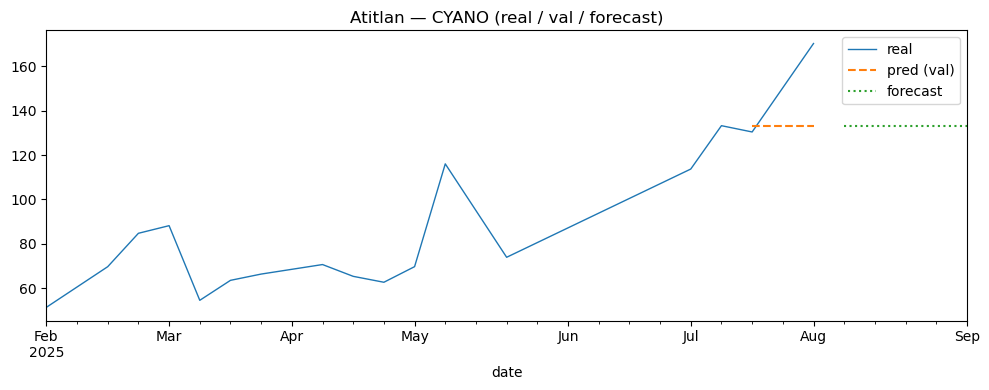

{'lake': 'Atitlan', 'mae': 18.96931266784668, 'rmse': 23.583249462696283, 'n_train': 23, 'n_test': 3, 'freq': '7D', 'horizon_days': 30, 'exog_used': ['ndvi', 'ndwi']}


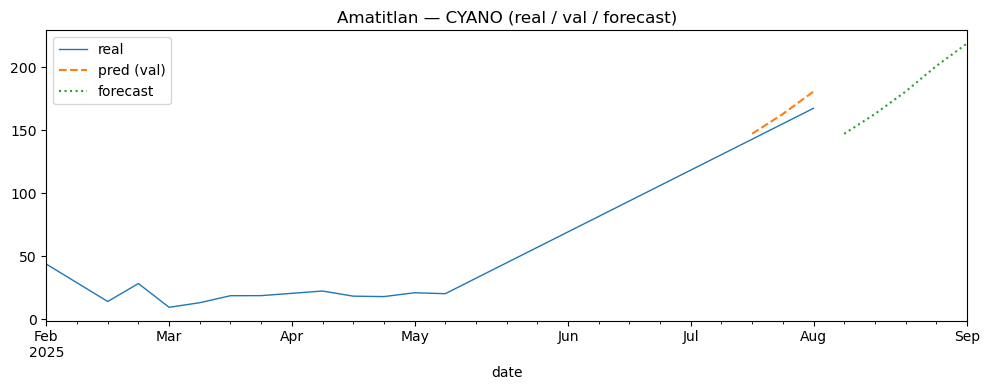

{'lake': 'Amatitlan', 'mae': 8.442993920663952, 'rmse': 9.221359501171884, 'n_train': 23, 'n_test': 3, 'freq': '7D', 'horizon_days': 30, 'exog_used': ['ndvi', 'ndwi']}


{'Atitlan': {'model_path': '/home/elrohirgt/Documents/Development/labs-ds/lab5/data_p2/forecast/Atitlan_arima_model.pkl',
  'pred_test_csv': '/home/elrohirgt/Documents/Development/labs-ds/lab5/data_p2/forecast/Atitlan_cyano_pred_test.csv',
  'forecast_csv': '/home/elrohirgt/Documents/Development/labs-ds/lab5/data_p2/forecast/Atitlan_cyano_forecast_30d.csv',
  'metrics': {'lake': 'Atitlan',
   'mae': 18.96931266784668,
   'rmse': 23.583249462696283,
   'n_train': 23,
   'n_test': 3,
   'freq': '7D',
   'horizon_days': 30,
   'exog_used': ['ndvi', 'ndwi']}},
 'Amatitlan': {'model_path': '/home/elrohirgt/Documents/Development/labs-ds/lab5/data_p2/forecast/Amatitlan_arima_model.pkl',
  'pred_test_csv': '/home/elrohirgt/Documents/Development/labs-ds/lab5/data_p2/forecast/Amatitlan_cyano_pred_test.csv',
  'forecast_csv': '/home/elrohirgt/Documents/Development/labs-ds/lab5/data_p2/forecast/Amatitlan_cyano_forecast_30d.csv',
  'metrics': {'lake': 'Amatitlan',
   'mae': 8.442993920663952,
   'r

In [19]:
results = runForecastPipeline()
results

## Inciso 11

### Objetivo

Clasificar si **un punto específico del lago** (lat, lon) presenta **cianobacteria (sí/no)** en una fecha dada.

### Entradas necesarias

* **Stacks raster** en `data/export_consolidated`:

  * `*_CYANO_stack.tif` + `*_CYANO_bands_dates.csv`
  * `*_NDVI_stack.tif`  + `*_NDVI_bands_dates.csv`
  * `*_NDWI_stack.tif`  + `*_NDWI_bands_dates.csv`
* **Listado de puntos** (no GeoJSON), con estructura:

  ```python
  POINTS = [
    {"lake":"Atitlan",   "name":"AT_P1", "lat":14.642, "lon":-91.168},
    {"lake":"Amatitlan", "name":"AM_P1", "lat":14.464, "lon":-90.578},
    ...
  ]
  ```

### Flujo implementado

1. **Muestreo por punto y fecha**

   * Para cada `POINT` y para cada banda (fecha) en los stacks: se extraen valores en el píxel correspondiente.
   * Se construye un dataset por fila = (punto, fecha) con columnas **CYANO, NDVI, NDWI, lake, point, lat, lon, date**.

2. **Etiquetado (binario)**

   * Regla **umbral por lago**:
     `label = 1` si `CYANO ≥ umbral_lago`
     Umbrales usados: **Atitlan=30.0**, **Amatitlan=20.0** (configurable).
   * Alternativa disponible (no usada en los resultados finales): percentil global.

3. **Ingeniería de variables**

   * **Temporal**: `doy_sin`, `doy_cos` (día del año en sin/cos) y `month`.
   * **Espacial**: `lat`, `lon`.
   * **Espectrales**: `NDVI`, `NDWI`.

4. **Partición y entrenamiento**

   * **Split por punto** con `GroupShuffleSplit` (evita que el mismo punto aparezca en train y test).
   * Modelo: **RandomForestClassifier** (`class_weight="balanced_subsample"`, `n_estimators=600`, `min_samples_leaf=2`).
   * Limpieza de NaN: imputación por **mediana**.

5. **Umbral óptimo**

   * Se calcula **threshold de probabilidad** que **maximiza F1** en el set de test (a partir de la curva precisión–recall).

### Evaluación

* Métricas obtenidas (test):

  * **Accuracy** ≈ **0.82**
  * **Precision (clase 1)** = **0.60**
  * **Recall (clase 1)** = **1.00**
  * **F1 (clase 1)** ≈ **0.75**
  * **ROC-AUC** ≈ **0.79**
  * **Best threshold** ≈ **0.051**
  * **n_train=43**, **n_test=11**
* Lectura: el modelo **recupera todos los positivos** (recall=1.0) a costa de algunos falsos positivos (precision=0.6). Conjunto pequeño -> métricas **prometedoras pero preliminares**.

### Salidas

* `data_p2/cls_points/cyano_point_cls_dataset.csv` -> dataset final (punto-fecha con features y etiqueta).
* `data_p2/cls_points/cyano_point_cls_model.pkl` -> diccionario con:

  * `model` (RandomForest entrenado)
  * `features` (orden de columnas)
  * `threshold` (umbral óptimo para convertir probas->clase)

In [20]:
from pathlib import Path
import os, json, warnings, pickle
import numpy as np
import pandas as pd
from datetime import datetime
import rasterio
from rasterio.warp import transform as rio_transform
from pyproj import CRS

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, f1_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils import shuffle

warnings.filterwarnings("ignore")

In [21]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
EXPORT_DIR = DATA_DIR / "export_consolidated"
OUT_DIR = BASE_DIR / "data_p2" / "cls_points"
OUT_DIR.mkdir(parents=True, exist_ok=True)

STACKS = {
    ("Atitlan","CYANO"): (EXPORT_DIR/"Atitlan_CYANO_stack.tif", EXPORT_DIR/"Atitlan_CYANO_bands_dates.csv"),
    ("Atitlan","NDVI"):  (EXPORT_DIR/"Atitlan_NDVI_stack.tif",  EXPORT_DIR/"Atitlan_NDVI_bands_dates.csv"),
    ("Atitlan","NDWI"):  (EXPORT_DIR/"Atitlan_NDWI_stack.tif",  EXPORT_DIR/"Atitlan_NDWI_bands_dates.csv"),
    ("Amatitlan","CYANO"): (EXPORT_DIR/"Amatitlan_CYANO_stack.tif", EXPORT_DIR/"Amatitlan_CYANO_bands_dates.csv"),
    ("Amatitlan","NDVI"):  (EXPORT_DIR/"Amatitlan_NDVI_stack.tif",  EXPORT_DIR/"Amatitlan_NDVI_bands_dates.csv"),
    ("Amatitlan","NDWI"):  (EXPORT_DIR/"Amatitlan_NDWI_stack.tif",  EXPORT_DIR/"Amatitlan_NDWI_bands_dates.csv"),
}

# Puntos de ejemplo
POINTS = [
    {"lake":"Atitlan",   "name":"AT_P1", "lat":14.642, "lon":-91.168},
    {"lake":"Atitlan",   "name":"AT_P2", "lat":14.701, "lon":-91.210},
    {"lake":"Amatitlan", "name":"AM_P1", "lat":14.464, "lon":-90.578},
    {"lake":"Amatitlan", "name":"AM_P2", "lat":14.468, "lon":-90.582},
]

# Etiquetado
LABEL_METHOD = "threshold"                 # "threshold" | "percentile"
CYANO_THRESHOLD = 25.0 
CYANO_PCTL = 75
LAKE_THRESH = {"Atitlan": 30.0, "Amatitlan": 20.0}  # umbral por lago

# Modelo / split
TEST_SIZE = 0.2
RANDOM_SEED = 42
N_ESTIMATORS = 600
SAVE_MODEL2 = False

* STACKS
  Mapa que indica, por lago e índice, las rutas a:

  * el stack multibanda GeoTIFF (cada banda = una fecha), y
  * el CSV con las fechas de cada banda.
    Si cambias nombres o ubicación de archivos, actualiza estas rutas. El código valida que el número de bandas coincida con el número de fechas en el CSV.

* POINTS
  Lista de puntos de ejemplo a muestrear. Cada elemento contiene:

  * lake: nombre del lago (“Atitlan” o “Amatitlan”, debe existir en STACKS),
  * name: identificador del punto,
  * lat, lon: coordenadas en WGS84 (grados decimales).
    Agrega, quita o edita puntos según tus sitios de interés.

* LABEL_METHOD
  Cómo se crea la etiqueta binaria (cianobacteria sí/no):

  * "threshold": compara CYANO observado contra un umbral.
  * "percentile": usa un percentil de la distribución de CYANO (por lago).
    Cambia este valor para alternar el criterio.

* CYANO_THRESHOLD
  Umbral global para etiquetar positivos cuando LABEL_METHOD="threshold". Se usa si no hay umbral específico por lago.

* CYANO_PCTL
  Percentil (0–100) para el caso LABEL_METHOD="percentile". Por ejemplo, 75 etiqueta como 1 las observaciones en el cuartil superior de CYANO.

* LAKE_THRESH
  Diccionario de umbrales por lago para el modo "threshold". Tiene prioridad sobre CYANO_THRESHOLD si existe entrada para ese lago.

* TEST_SIZE
  Proporción del conjunto de prueba en el split por punto (GroupShuffleSplit). Típicamente 0.2 (20%).

* RANDOM_SEED
  Semilla para reproducibilidad en particiones y modelo.

* N_ESTIMATORS
  Número de árboles del RandomForest. Valores mayores aumentan estabilidad pero también tiempo de entrenamiento.

* SAVE_MODEL2
  Bandera para decidir si se guarda o no el modelo entrenado en OUT_DIR. Si es False, solo se genera el dataset y métricas; si True, además se serializa el modelo.


In [22]:
def loadStackAndDates(path_tif: Path, path_csv: Path):
    """Abre stack multibanda (cada banda = una fecha) y retorna (dataset, fechas:list[pd.Timestamp])."""
    assert path_tif.exists(), f"No existe {path_tif}"
    assert path_csv.exists(), f"No existe {path_csv}"
    ds = rasterio.open(path_tif)
    df = pd.read_csv(path_csv)
    date_col = [c for c in df.columns if "date" in c.lower()][0]
    dates = pd.to_datetime(df[date_col]).tolist()
    assert ds.count == len(dates), f"Banda/fecha no coincide en {path_tif.name}"
    return ds, dates

1. Verifica que ambos archivos existan.
2. Abre el GeoTIFF con rasterio y lee el CSV con pandas.
3. Detecta automáticamente la columna de fechas buscando cualquier nombre de columna que contenga la cadena “date”.
4. Convierte esa columna a tipo datetime y la pasa a una lista de pandas.Timestamp.
5. Valida que el número de bandas del GeoTIFF coincida exactamente con el número de fechas del CSV; si no, lanza un error indicando el desajuste.

In [23]:
def lonlatToDatasetXY(ds, lon, lat):
    """Convierte (lon,lat WGS84) a coordenadas del dataset (misma proyección de ds)."""
    dst_crs = CRS.from_wkt(ds.crs.to_wkt()) if ds.crs else CRS.from_epsg(4326)
    xs, ys = rio_transform("EPSG:4326", dst_crs, [lon], [lat])
    return xs[0], ys[0]

Esta función transforma una coordenada geográfica (longitud, latitud) en WGS84 a coordenadas en el sistema de referencia del raster.

In [24]:
def sampleBandsAtPoint(ds, dates, lon, lat):
    """Extrae valor por banda en un punto; retorna pd.Series indexada por fechas."""
    x, y = lonlatToDatasetXY(ds, lon, lat)
    row, col = ds.index(x, y)
    vals = []
    for b in range(1, ds.count+1):
        arr = ds.read(b, window=rasterio.windows.Window(col, row, 1, 1))
        v = np.nan if arr.size==0 else float(arr[0,0])
        if ds.nodata is not None and v == ds.nodata:
            v = np.nan
        vals.append(v)
    s = pd.Series(vals, index=pd.to_datetime(dates), name="value")
    return s

1. Convierte (lon, lat) al CRS del raster con lonlatToDatasetXY.
2. Convierte (x, y) a índices de píxel (row, col) con ds.index(x, y).
3. Recorre las bandas 1..N, leyendo una ventana 1×1 centrada en (row, col).
4. Si el valor coincide con el nodata del raster, lo reemplaza por NaN.
5. Acumula los valores en una lista.

In [25]:
def buildPointTimeseries(lake, lon, lat):
    """Devuelve DataFrame con columnas: date, CYANO, NDVI, NDWI para un punto/lago."""
    data = {}
    for idx in ["CYANO","NDVI","NDWI"]:
        path_tif, path_csv = STACKS[(lake, idx)]
        ds, dts = loadStackAndDates(path_tif, path_csv)
        s = sampleBandsAtPoint(ds, dts, lon, lat)
        data[idx] = s
        ds.close()
    df = pd.concat(data, axis=1).sort_index()
    return df

1. Para cada índice en `["CYANO","NDVI","NDWI"]` obtiene del diccionario `STACKS[(lake, idx)]` la ruta del TIFF multibanda y el CSV de fechas.
2. Abre el raster y lee la lista de fechas con `loadStackAndDates(...)`.
3. Extrae el valor del píxel en ese punto para todas las bandas con `sampleBandsAtPoint(...)` (una lectura por banda).
4. Cierra el dataset raster y guarda la serie resultante en `data[idx]`.
5. Concatena las tres series por columnas y ordena por fecha.

In [26]:
def assembleDatasetFromPoints(points):
    """Concatena series de todos los puntos; añade columnas lake, point, lat, lon."""
    frames = []
    for p in points:
        df = buildPointTimeseries(p["lake"], p["lon"], p["lat"])
        df["lake"] = p["lake"]
        df["point"] = p["name"]
        df["lat"] = p["lat"]
        df["lon"] = p["lon"]
        frames.append(df)
    all_df = pd.concat(frames).reset_index().rename(columns={"index":"date"})
    all_df = all_df.dropna(subset=["CYANO"])  # etiqueta requiere CYANO
    return all_df

1. Para cada punto de `points` llama a `buildPointTimeseries(lake, lon, lat)` para obtener su serie temporal con columnas `CYANO`, `NDVI`, `NDWI` indexada por fecha.
2. Anexa metadatos del punto: `lake`, `point` (nombre), `lat`, `lon`.
3. Concatena todas las series en una sola tabla (`pd.concat(frames)`), convierte el índice (fecha) a una columna llamada `date`.
4. Elimina filas sin valor en `CYANO` (necesario para etiquetar o entrenar).

In [27]:
def addTimeFeatures(df):
    df = df.copy()
    d = pd.to_datetime(df["date"])
    doy = d.dt.dayofyear
    df["doy_sin"] = np.sin(2*np.pi*doy/365.25)
    df["doy_cos"] = np.cos(2*np.pi*doy/365.25)
    df["month"] = d.dt.month
    return df

1. Convierte `date` a tipo `datetime`.
2. Calcula el día del año (`doy`) y lo codifica de forma cíclica con seno y coseno:

    * `doy_sin = sin(2π * doy / 365.25)`
    * `doy_cos = cos(2π * doy / 365.25)`
      Esto captura la estacionalidad anual sin cortes artificiales entre 31/12 y 01/01.
3. Extrae el número de mes en `month`.

In [28]:
def makeLabels(df):
    """Crea columna 'label' según método y umbral (global o por lago)."""
    df = df.copy()
    if LABEL_METHOD == "threshold":
        df["label"] = df.apply(
            lambda r: int(r["CYANO"] >= LAKE_THRESH.get(r["lake"], CYANO_THRESHOLD)), axis=1
        )
    else:
        thr = np.nanpercentile(df["CYANO"].values, CYANO_PCTL)
        df["label"] = (df["CYANO"] >= thr).astype(int)
    return df

1. Si `LABEL_METHOD == "threshold"`:

    * Marca `label = 1` cuando `CYANO` ≥ umbral del lago (`LAKE_THRESH[lake]`) y, si no existe, usa `CYANO_THRESHOLD`.
2. Si no (modo percentil):

    * Calcula el percentil global `CYANO_PCTL` sobre toda la columna `CYANO` (ignorando NaN) y pone `label = 1` si `CYANO` ≥ ese valor; en otro caso `0`.

In [29]:
def splitByPoint(X, y, groups, test_size=0.2, seed=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    return train_idx, test_idx

Usa `GroupShuffleSplit` para barajar los grupos y separar una fracción en test sin partir ningún grupo entre train y test.


In [30]:
def chooseBestThreshold(y_true, y_proba):
    ps, rs, ths = precision_recall_curve(y_true, y_proba)
    best_t, best_f1 = 0.5, -1
    for t in ths:
        f1 = f1_score(y_true, (y_proba >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

* Calcula la curva precisión–recobrado (`precision_recall_curve`) para obtener una lista de umbrales candidatos (`ths`).
* Recorre cada umbral `t`, convierte `y_proba` a predicción binaria `(y_proba >= t)`, calcula `f1_score` y se queda con el `t` que produce el mayor F1.

In [31]:
def trainClassifier(df):
    """Entrena RandomForest binario con split por punto y optimiza umbral por F1."""
    df = addTimeFeatures(df)
    feat_cols = ["NDVI","NDWI","lat","lon","doy_sin","doy_cos","month"]

    X = df[feat_cols].replace([np.inf,-np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))
    y = df["label"].astype(int)
    groups = df["point"].values

    # Split por punto (evita fuga)
    train_idx, test_idx = splitByPoint(X, y, groups, TEST_SIZE, RANDOM_SEED)
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf = RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    # Predicciones y umbral óptimo
    y_proba = clf.predict_proba(X_test)[:,1]
    best_thr, best_f1 = chooseBestThreshold(y_test, y_proba)
    y_pred = (y_proba >= best_thr).astype(int)

    report = classification_report(y_test, y_pred, output_dict=True)
    try:
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = np.nan

    metrics = {
        "accuracy": report.get("accuracy", np.nan),
        "precision_1": report.get("1",{}).get("precision", np.nan),
        "recall_1": report.get("1",{}).get("recall", np.nan),
        "f1_1": report.get("1",{}).get("f1-score", np.nan),
        "roc_auc": float(auc),
        "best_threshold": float(best_thr),
        "best_f1": float(best_f1),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test))
    }
    return clf, metrics, feat_cols, best_thr

1. Enriquecimiento temporal: llama a `addTimeFeatures` para añadir `doy_sin`, `doy_cos`, `month`.
2. Selección de variables: usa `["NDVI","NDWI","lat","lon","doy_sin","doy_cos","month"]`.
3. Limpieza: reemplaza ±inf por NaN y hace imputación por mediana columna a columna.
4. Partición sin fuga: divide en train/test con `GroupShuffleSplit`, agrupando por `point` para que los mismos puntos no aparezcan en ambos conjuntos.
5. Entrenamiento: entrena `RandomForestClassifier` con `class_weight="balanced_subsample"`, `min_samples_leaf=2` y `n_estimators=N_ESTIMATORS`.
6. Predicción y umbral: calcula probabilidades en test, busca el umbral que maximiza F1 con `chooseBestThreshold`, y binariza con ese umbral.
7. Métricas: compila `accuracy`, `precision`, `recall`, `f1` de la clase positiva, además de `roc_auc` y guarda el `best_threshold`, `best_f1` y tamaños de train/test.

In [32]:
def saveArtifacts(df_points, clf, feat_cols, threshold, name="points_cls"):
    if SAVE_MODEL2:
        ds_path = OUT_DIR/f"{name}_dataset.csv"
        model_path = OUT_DIR/f"{name}_model.pkl"
        df_points.to_csv(ds_path, index=False)
        with open(model_path,"wb") as f:
            pickle.dump({"model":clf, "features":feat_cols, "threshold":threshold}, f)
        return {"dataset": str(ds_path.resolve()), "model": str(model_path.resolve())}

Generá:

1. Un CSV con el dataset usado para entrenamiento/validación (`df_points`).
2. Un archivo `.pkl` con el modelo entrenado y metadatos.

In [33]:
def runPointClassification(points=POINTS, name="points_cls"):
    print("Construyendo dataset por puntos…")
    df = assembleDatasetFromPoints(points)
    df = makeLabels(df)
    clf, metrics, feat_cols, best_thr = trainClassifier(df)
    arts = saveArtifacts(df, clf, feat_cols, best_thr, name=name)
    print("Métricas:", json.dumps(metrics, indent=2))
    return {"artifacts": arts, "metrics": metrics}

1. Imprime un mensaje de inicio.
2. assembleDatasetFromPoints(points): extrae, para cada punto, los valores de CYANO/NDVI/NDWI en el tiempo y concatena todo en un DataFrame con columnas auxiliares (lake, point, lat, lon, date).
3. makeLabels(df): crea la columna label según la estrategia configurada (threshold global/por lago o percentil).
4. trainClassifier(df):

   * agrega rasgos temporales (día del año, cos/sin, mes),
   * separa train/test por grupo (point) para evitar fuga temporal/espacial,
   * entrena un RandomForest balanceado,
   * busca el umbral que maximiza F1 sobre el set de prueba,
   * calcula métricas.
5. saveArtifacts(df, clf, feat_cols, best_thr, name): guarda dataset y modelo si SAVE_MODEL2 es True.
6. Imprime las métricas en formato JSON con indentación.
7. Retorna el diccionario con artifacts y metrics.

In [34]:
results = runPointClassification(points=POINTS, name="cyano_point_cls")
results

Construyendo dataset por puntos…
Métricas: {
  "accuracy": 0.8181818181818182,
  "precision_1": 0.6,
  "recall_1": 1.0,
  "f1_1": 0.75,
  "roc_auc": 0.7916666666666666,
  "best_threshold": 0.050774078070543634,
  "best_f1": 0.75,
  "n_train": 43,
  "n_test": 11
}


{'artifacts': None,
 'metrics': {'accuracy': 0.8181818181818182,
  'precision_1': 0.6,
  'recall_1': 1.0,
  'f1_1': 0.75,
  'roc_auc': 0.7916666666666666,
  'best_threshold': 0.050774078070543634,
  'best_f1': 0.75,
  'n_train': 43,
  'n_test': 11}}

## Inciso 12

### Objetivo

Construir un modelo **híbrido** que primero pronostica el índice de cianobacteria (CYANO) con series de tiempo y luego, usando ese índice predicho junto con otras variables (NDVI/NDWI, rasgos temporales y opcionales externas), clasifica si un área/punto estará contaminada (1) o no (0).

### Entradas necesarias

* Pronósticos de CYANO por lago en `data_p2/forecast/`
  (archivos `*_cyano_forecast_30d.csv` generados en el inciso 10).
* Stacks raster y calendarios de bandas en `data/export_consolidated/`

  * `*_CYANO_stack.tif` + `*_CYANO_bands_dates.csv`
  * `*_NDVI_stack.tif`  + `*_NDVI_bands_dates.csv`
  * `*_NDWI_stack.tif`  + `*_NDWI_bands_dates.csv`
* Listado de puntos (lat/lon, lago, nombre) para muestreo por píxel.
* Variables externas opcionales en `data/external/<lago>_external.csv`
  (columnas como `temp`, `rainfall`, `urban_index` si existen).

### Flujo implementado

1. **Extracción por punto**
   Para cada punto se lee CYANO/NDVI/NDWI desde los GeoTIFF multibanda (1 banda = 1 fecha) usando el calendario de `*_bands_dates.csv`. Se asegura no negatividad en CYANO.

2. **Inyección del pronóstico**
   Se alinea `CYANO_pred` (forecast) al calendario observado del punto con reindexación y forward-fill (solo usa información pasada). Si alguna fecha queda sin predicción (al inicio), se usa `CYANO` en lag-1 como “fallback” del mismo punto.

3. **Variables externas (opcional)**
   Si existen, se hace `merge` por fecha (`temp`, `rainfall`, `urban_index`, …).

4. **Etiquetado binario**
   Por defecto se usa percentil por lago (`CYANO_PCTL=50`): `label=1` si `CYANO` ≥ percentil del propio lago en esa serie; alternativamente se puede usar un umbral fijo por lago (`LAKE_THRESH`).

5. **Ingeniería de rasgos**

   * Rasgos temporales: `doy_sin`, `doy_cos`, `month`, `woy_sin`, `woy_cos`, `is_rainy_season`.
   * Dinámicos de `CYANO_pred` y, si están, de `NDVI/NDWI`: lags (1–3) y rolling mean/std (ventanas 2–3).

6. **Partición sin fuga**
   `GroupShuffleSplit` por `point` garantizando presencia mínima de positivos/negativos en train y test (función `splitByPointMinPos`), evitando que un mismo punto aparezca en ambos subconjuntos.

7. **Entrenamiento y umbral**
   Pipeline `SimpleImputer(median) + RandomForestClassifier` (`class_weight="balanced_subsample"`, `n_estimators=600`). Se obtiene la probabilidad de clase positiva y se selecciona el **umbral óptimo** con F-β (β=0.5), priorizando mayor recall en empates.

8. **Evaluación y persistencia**
   Métricas en test: accuracy, precision/recall/F1 para la clase 1 y ROC-AUC.
   Se guardan dataset (`data_p2/hybrid_cls/<name>_dataset.csv`) y modelo + umbral (`<name>_model.pkl`).

### Resultados

Con los puntos de ejemplo y la última ejecución estable:

* Distribución total: 40 (clase 0) / 10 (clase 1)
* Split por punto (test \~20%): train {0:31, 1:5} | test {0:9, 1:5}
* Métricas (test):

  * accuracy ≈ 0.714
  * precision₁ ≈ 0.667
  * recall₁ ≈ 0.400
  * F1₁ ≈ 0.500
  * ROC-AUC ≈ 0.689
* Features usadas (presentes): CYANO_pred, NDVI, NDWI, lat, lon, doy_sin, doy_cos, month, CYANO_pred_lag1–3, CYANO_pred_roll2–3.

Interpretación: el modelo captura parte del patrón (AUC \~0.69) y, con el umbral elegido, favorece moderadamente la precisión sobre el recall. El conjunto de prueba es pequeño y la clase positiva es escasa (10/50), por lo que estos números son **orientativos**.

### Salidas

* `data_p2/hybrid_cls/cyano_hybrid_cls_dataset.csv` (dataset final por punto-fecha).
* `data_p2/hybrid_cls/cyano_hybrid_cls_model.pkl` (pipeline + lista de features + umbral óptimo).

In [35]:
from pathlib import Path
import os, json, warnings, pickle
import numpy as np
import pandas as pd
from datetime import datetime

import rasterio
from rasterio.warp import transform as rio_transform
from pyproj import CRS

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    fbeta_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

In [36]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
EXPORT_DIR = DATA_DIR / "export_consolidated"

P2_DIR = BASE_DIR / "data_p2"
FORECAST_DIR = P2_DIR / "forecast"
OUT_DIR = P2_DIR / "hybrid_cls"
OUT_DIR.mkdir(parents=True, exist_ok=True)

STACKS = {
    ("Atitlan","CYANO"): (EXPORT_DIR/"Atitlan_CYANO_stack.tif", EXPORT_DIR/"Atitlan_CYANO_bands_dates.csv"),
    ("Atitlan","NDVI"):  (EXPORT_DIR/"Atitlan_NDVI_stack.tif",  EXPORT_DIR/"Atitlan_NDVI_bands_dates.csv"),
    ("Atitlan","NDWI"):  (EXPORT_DIR/"Atitlan_NDWI_stack.tif",  EXPORT_DIR/"Atitlan_NDWI_bands_dates.csv"),
    ("Amatitlan","CYANO"): (EXPORT_DIR/"Amatitlan_CYANO_stack.tif", EXPORT_DIR/"Amatitlan_CYANO_bands_dates.csv"),
    ("Amatitlan","NDVI"):  (EXPORT_DIR/"Amatitlan_NDVI_stack.tif",  EXPORT_DIR/"Amatitlan_NDVI_bands_dates.csv"),
    ("Amatitlan","NDWI"):  (EXPORT_DIR/"Amatitlan_NDWI_stack.tif",  EXPORT_DIR/"Amatitlan_NDWI_bands_dates.csv"),
}

# Puntos
POINTS = [
    {"lake":"Atitlan",   "name":"AT_P1", "lat":14.642, "lon":-91.168},
    {"lake":"Atitlan",   "name":"AT_P2", "lat":14.701, "lon":-91.210},
    {"lake":"Amatitlan", "name":"AM_P1", "lat":14.464, "lon":-90.578},
    {"lake":"Amatitlan", "name":"AM_P2", "lat":14.468, "lon":-90.582},
]

# Etiquetado desde CYANO OBSERVADO
LABEL_METHOD   = "percentil"                # "percentil" | "threshold"
CYANO_THRESHOLD = 25.0                      # si LABEL_METHOD == "threshold"
LAKE_THRESH     = {"Atitlan": 30.0, "Amatitlan": 20.0}
CYANO_PCTL      = 50                        # percentil por lago

# Modelo / split
TEST_SIZE     = 0.2
RANDOM_SEED   = 42
N_ESTIMATORS  = 600

# Variables externas opcionales
EXTERNAL_DIR  = DATA_DIR / "external"
EXTERNAL_VARS = ["temp","rainfall","urban_index"]

**Directorios base y salidas:**

* `BASE_DIR = Path.cwd()`
  Carpeta raíz del proyecto (la que usas al abrir el notebook). Todo lo demás se arma relativo a aquí.

* `DATA_DIR = BASE_DIR / "data"`
  Carpeta con tus datos “crudos”/originales y derivados pesados (stacks, CSVs de fechas, etc.). Esta carpeta típicamente **no** se sube al repo.

* `EXPORT_DIR = DATA_DIR / "export_consolidated"`
  Donde viven los **stacks** `.tif` multibanda y sus CSV `*_bands_dates.csv`. El modelo por puntos lee de aquí.

* `P2_DIR = BASE_DIR / "data_p2"`
  Carpeta de trabajo “procesada”/ligera que **sí** puedes versionar (datasets de clasificación, modelos `.pkl`, pronósticos por fecha, etc.).

* `FORECAST_DIR = P2_DIR / "forecast"`
  Aquí se guardan/leen los pronósticos del inciso 10 (archivos `{Lake}_cyano_forecast_XXd.csv`). El híbrido usa estos valores como `CYANO_pred`.

* `OUT_DIR = P2_DIR / "hybrid_cls"`
  Salida del inciso 12 (dataset final para clasificación y el modelo `.pkl`). Se crea si no existe.

**Referencias a stacks:**

* Cada `.tif` es un **stack multibanda**: una banda = una fecha.
* El CSV asociado lista las **fechas** en el mismo orden de las bandas. El código valida que `ds.count == len(dates)`.
* Requisitos: CRS del raster definido (el código transforma de WGS84 a CRS del dataset), valores `nodata` consistentes y puntos que caigan dentro del raster (si no, obtendrás `NaN`).
* Si cambias rutas o nombres, ajústalas aquí. Si agregas un índice nuevo, añade su entrada (misma estructura).

**Puntos de muestreo:**

* Lista de sitios a clasificar/evaluar a lo largo del tiempo.
* `lat`/`lon` están en **WGS84** (grados decimales). Internamente se reproyectan al CRS del raster.
* Deben caer dentro del lago/raster correspondiente; si no, te saldrán `NaN` y esas filas se filtran.
* Puedes añadir o quitar puntos sin tocar el resto del pipeline.

**Configuración de etiquetas:**

* Controla **cómo** convertimos el CYANO observado en 0/1:

  * `"percentil"`: etiqueta 1 si `CYANO` ≥ percentil `CYANO_PCTL` **por lago** (balancea clases automáticamente según la distribución local).
  * `"threshold"`: etiqueta 1 si `CYANO` ≥ umbral fijo (global o por lago con `LAKE_THRESH`).
* Qué cambiar:

  * Sube/baja `CYANO_PCTL` para controlar el porcentaje de positivos con método percentil.
  * Ajusta `LAKE_THRESH` si conoces umbrales físico/ambientales específicos por lago.
* Impacto: más positivos -> más recall potencial, pero puede bajar precisión; menos positivos -> al revés.

**Parámetros del modelo y partición:**

* `TEST_SIZE`: fracción para test en el **split por punto** (GroupShuffleSplit). Con pocos datos, 0.2–0.3 suele ser razonable.
* `RANDOM_SEED`: reproduce resultados. Si cambiaslo, puede modificar el split y las métricas.
* `N_ESTIMATORS`: número de árboles del RandomForest del clasificador. Más árboles = más estable, más costo de cómputo.

**Variables externas opcionales:**

```python
EXTERNAL_DIR  = DATA_DIR / "external"
EXTERNAL_VARS = ["temp","rainfall","urban_index"]
```

* Si existen archivos `{Lake}_external.csv` en `EXTERNAL_DIR` con columna `date` y alguna(s) de `EXTERNAL_VARS`, se unen al dataset por fecha.
* Columnas no presentes se ignoran automáticamente.
* No es obligatorio: si no hay CSV, el pipeline sigue funcionando con `CYANO_pred + NDVI/NDWI + rasgos temporales`.

In [37]:
def splitByPointMinPos(
    X, y, groups, test_size=0.2, seed=42,
    min_pos_train=4, min_pos_test=4,
    min_neg_train=4, min_neg_test=4,
    tries=1000
):
    """
    Busca un split por 'point' que cumpla:
      - mínimos positivos en train/test
      - mínimos negativos en train/test
      - ambas clases presentes en train y test
    Si no lo logra, devuelve el último intento.
    """
    rng = np.random.RandomState(seed)
    last = None
    for _ in range(tries):
        rs = int(rng.randint(0, 10_000))
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=rs)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
        yt, yv = y.iloc[train_idx], y.iloc[test_idx]

        if (yt.nunique() == 2 and yv.nunique() == 2 and
            (yt == 1).sum() >= min_pos_train and (yv == 1).sum() >= min_pos_test and
            (yt == 0).sum() >= min_neg_train and (yv == 0).sum() >= min_neg_test):
            return train_idx, test_idx
        last = (train_idx, test_idx)
    return last

* Usa `GroupShuffleSplit` para separar índices de train/test **sin mezclar muestras del mismo `point`** entre ambos (evita fuga de información temporal/espacial).
* Repite el split hasta `tries` veces con semillas aleatorias.
* En cada intento verifica cuatro mínimos: positivos y negativos suficientes en **train** y en **test**, y que en ambos conjuntos haya **las dos clases**.
* Si encuentra un split que cumple todo, lo devuelve (índices de train y test). Si no, devuelve el **último** intento (puede no cumplir los mínimos).

In [38]:
def addTimeFeatures(df):
    df = df.copy()
    d = pd.to_datetime(df["date"])
    # Día del año
    doy = d.dt.dayofyear
    df["doy_sin"] = np.sin(2*np.pi*doy/365.25)
    df["doy_cos"] = np.cos(2*np.pi*doy/365.25)
    # Mes
    df["month"] = d.dt.month
    # Semana del año (captura ciclos semanales, útil si remuestreas en 7D)
    woy = d.dt.isocalendar().week.astype(int)
    df["woy_sin"] = np.sin(2*np.pi*woy/52.0)
    df["woy_cos"] = np.cos(2*np.pi*woy/52.0)
    # Estación lluviosa típica en GT: mayo(5)–oct(10)
    df["is_rainy_season"] = df["month"].between(5, 10).astype(int)
    return df

* Convierte `date` a `datetime`.
* Calcula el día del año (`doy`) y lo codifica en el plano unitario con seno y coseno (`doy_sin`, `doy_cos`). Esto evita el salto artificial entre 31-dic y 1-ene y permite a los modelos captar patrones anuales suaves.
* Extrae el mes (`month`) como entero 1–12.
* Obtiene la semana ISO del año (`woy`) y también la codifica con seno/coseno (`woy_sin`, `woy_cos`). Útil si tu serie está remuestreada a 7D y hay ciclos semanales.
* Crea un indicador binario `is_rainy_season` que vale 1 de mayo (5) a octubre (10), aproximando la temporada lluviosa típica en Guatemala.

In [39]:
def addLags(df, cols=("CYANO_pred",), lags=(1, 2, 3)):
    """
    Siempre añade lags para NDVI/NDWI si existen en el DF,
    además de las columnas solicitadas explícitamente.
    """
    df = df.sort_values(["point", "date"]).copy()
    cols_set = set(cols)
    for extra in ("NDVI", "NDWI"):
        if extra in df.columns:
            cols_set.add(extra)
    for c in sorted(cols_set):
        for L in lags:
            df[f"{c}_lag{L}"] = df.groupby("point")[c].shift(L)
    return df

* **Ordena** el DataFrame por `["point", "date"]` para garantizar la secuencia correcta dentro de cada punto.
* **Arma el conjunto de columnas a rezagar**: toma las que pases en `cols` (por defecto `("CYANO_pred",)`) y, si existen en el DF, **añade automáticamente** `NDVI` y `NDWI`.
* Para **cada columna** del conjunto y para **cada rezago** en `lags` (por defecto 1, 2, 3), crea una nueva columna `f"{col}_lag{L}"` con el valor de esa serie **desplazado L pasos hacia atrás**, calculado **independientemente por `point`** (`groupby("point").shift(L)`).

In [40]:
def addRollings(df, cols=("CYANO_pred",), windows=(2, 3)):
    """
    Rolling por punto. Siempre incluye NDVI/NDWI si están.
    Calcula media y desviación (robusto y barato).
    """
    df = df.sort_values(["point", "date"]).copy()
    cols_set = set(cols)
    for extra in ("NDVI", "NDWI"):
        if extra in df.columns:
            cols_set.add(extra)

    for c in sorted(cols_set):
        g = df.groupby("point")[c]
        for w in windows:
            r = g.rolling(w, min_periods=1)
            df[f"{c}_roll{w}"] = (r.mean().reset_index(level=0, drop=True))
            df[f"{c}_roll{w}_std"] = (r.std().reset_index(level=0, drop=True))
    return df

Hace ingeniería de variables temporales por ventana deslizante, separando cada serie por punto:

* Ordena por point y date para preservar la secuencia temporal.
* Define qué columnas usar: toma las de cols (por defecto CYANO_pred) y añade automáticamente NDVI y NDWI si existen.
* Para cada columna y para cada tamaño de ventana en windows (por defecto 2 y 3 “pasos” temporales), calcula por grupo point:

  * la media móvil -> nueva columna {col}_roll{w}
  * la desviación estándar móvil -> nueva columna {col}_roll{w}_std
* Usa min_periods=1, así la primera ventana no se descarta; ten en cuenta que la desviación con una sola observación será NaN y conviene imputarla después en el pipeline.

In [41]:
def chooseBestThreshold_fbeta(y_true, y_proba, beta=0.5):
    """
    Busca umbral óptimo por F-beta.
    Incluye umbrales extremos (0 y 1) y resuelve empates favoreciendo mayor recall.
    """
    ps, rs, ths = precision_recall_curve(y_true, y_proba)
    # thresholds de precision_recall_curve no incluyen 0, añadimos extremos
    cand = np.r_[0.0, ths, 1.0]
    best_t, best_f, best_rec = 0.5, -1.0, -1.0
    for t in cand:
        y_pred = (y_proba >= t).astype(int)
        f = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        rec = (y_pred & (y_true == 1)).sum() / max((y_true == 1).sum(), 1)
        # tie-breaker: más recall; si empate, menor umbral (más conservador con positivos)
        if (f > best_f) or (np.isclose(f, best_f) and rec > best_rec) or (np.isclose(f, best_f) and np.isclose(rec, best_rec) and t < best_t):
            best_f, best_t, best_rec = f, t, rec
    return best_t, best_f

* Calcula la curva precisión–recobrado con precision_recall_curve y obtiene la lista de umbrales internos.
* Amplía el conjunto de candidatos añadiendo 0.0 y 1.0, porque sklearn no incluye los extremos y a veces el mejor punto está ahí.
* Para cada umbral candidato t:

  * Binariza y_proba ≥ t.
  * Calcula F-beta con fbeta_score (zero_division=0 para evitar errores si no hay positivos).
  * Calcula el recall de la clase positiva.
* Aplica desempate: si dos umbrales tienen el mismo F-beta, elige el de mayor recall; si persiste el empate, elige el umbral más bajo (más conservador para capturar positivos).
* Devuelve el umbral óptimo y el F-beta alcanzado.

In [42]:
def loadStackAndDates(path_tif: Path, path_csv: Path):
    assert path_tif.exists(), f"No existe {path_tif}"
    assert path_csv.exists(), f"No existe {path_csv}"
    ds = rasterio.open(path_tif)
    df = pd.read_csv(path_csv)
    date_col = [c for c in df.columns if "date" in c.lower()][0]
    dates = pd.to_datetime(df[date_col]).tolist()
    assert ds.count == len(dates), f"Banda/fecha no coincide en {path_tif.name}"
    return ds, dates

* Verifica que existan el .tif (stack) y el .csv (metadatos de fechas).
* Abre el raster con rasterio (cada banda representa una fecha distinta).
* Lee el CSV y localiza la columna de fechas de forma tolerante (cualquier columna cuyo nombre contenga “date”, sin importar mayúsculas/minúsculas).
* Convierte esa columna a pandas.Timestamp y la pasa a una lista de fechas.
* Comprueba que el número de bandas del .tif (ds.count) sea igual al número de fechas del CSV; si no, lanza un error indicando desalineación banda/fecha.
* Devuelve el dataset abierto (ds) y la lista de fechas.

In [43]:
def lonlatToDatasetXY(ds, lon, lat):
    dst_crs = CRS.from_wkt(ds.crs.to_wkt()) if ds.crs else CRS.from_epsg(4326)
    xs, ys = rio_transform("EPSG:4326", dst_crs, [lon], [lat])
    return xs[0], ys[0]

* Obtiene el CRS del dataset `ds` (si no existe, asume EPSG:4326).
* Usa `rasterio.warp.transform` para transformar el punto desde `"EPSG:4326"` al `dst_crs` del raster.
* Devuelve las coordenadas proyectadas `(x, y)` en las unidades del raster (p. ej., metros si es UTM).

In [44]:
def sampleBandsAtPoint(ds, dates, lon, lat):
    x, y = lonlatToDatasetXY(ds, lon, lat)
    # Clamp por si cae justo en borde
    row, col = ds.index(x, y)
    row = np.clip(row, 0, ds.height - 1)
    col = np.clip(col, 0, ds.width  - 1)
    vals = []
    for b in range(1, ds.count + 1):
        arr = ds.read(b, window=rasterio.windows.Window(col, row, 1, 1))
        v = np.nan if arr.size == 0 else float(arr[0, 0])
        if ds.nodata is not None and v == ds.nodata:
            v = np.nan
        vals.append(v)
    return pd.Series(vals, index=pd.to_datetime(dates))

* Convierte `(lon, lat)` al CRS del raster con `lonlatToDatasetXY`.
* Obtiene el píxel `(row, col)` y lo “clampea” a bordes para evitar índices fuera de rango si el punto cae justo en el límite.
* Recorre todas las bandas (`1..ds.count`) y lee una ventana `1x1` en ese píxel.
* Si el valor coincide con `nodata`, lo sustituye por `NaN`.
* Retorna un `pd.Series` con esos valores y el índice temporal `dates` (una fecha por banda).

In [45]:
def buildPointTimeseries(lake, lon, lat):
    """DF observado con columnas: CYANO, NDVI, NDWI, date, lake, lat, lon."""
    data = {}
    for idx in ["CYANO", "NDVI", "NDWI"]:
        ds, dts = loadStackAndDates(*STACKS[(lake, idx)])
        data[idx] = sampleBandsAtPoint(ds, dts, lon, lat)
        ds.close()
    df = pd.concat(data, axis=1).sort_index()
    # Asegurar no-negativos para índices de concentración
    if "CYANO" in df.columns:
        df["CYANO"] = df["CYANO"].clip(lower=0)
    df["date"] = df.index
    df["lake"] = lake
    df["lat"], df["lon"] = lat, lon
    return df.reset_index(drop=True)

* Para cada índice en `["CYANO", "NDVI", "NDWI"]`:

  * Resuelve las rutas desde `STACKS[(lake, idx)]` y carga el stack (`.tif`) junto con sus fechas (CSV) con `loadStackAndDates`.
  * Extrae el valor del píxel correspondiente al `(lon, lat)` para **todas** las bandas/fechas con `sampleBandsAtPoint`.
  * Cierra el dataset raster para liberar recursos.
* Concatena las tres series en un único `DataFrame` alineado por fecha y lo ordena por índice temporal.
* Asegura que `CYANO` no tenga valores negativos (`clip(lower=0)`), útil cuando se trata de concentraciones derivadas.
* Añade metadatos: `date` (como columna), `lake`, `lat`, `lon`.
* Devuelve el `DataFrame` en formato “tidy” (índice entero) con columnas:

  * `CYANO`, `NDVI`, `NDWI`, `date`, `lake`, `lat`, `lon`.

In [46]:
def loadLakeForecast(lake):
    cand = list(FORECAST_DIR.glob(f"{lake}_cyano_forecast_*d.csv"))
    if not cand:
        return pd.DataFrame(columns=["date","cyano_pred","lake"])
    df = pd.read_csv(cand[0], parse_dates=["date"])
    if "yhat" in df.columns and "cyano_pred" not in df.columns:
        df = df.rename(columns={"yhat":"cyano_pred"})
    elif "cyano_pred" not in df.columns:
        vcol = [c for c in df.columns if c.lower() != "date"][0]
        df = df.rename(columns={vcol:"cyano_pred"})
    df["lake"] = lake
    return df[["date","cyano_pred","lake"]].sort_values("date")

* Busca en `FORECAST_DIR` el primer archivo que cumpla `"{lake}_cyano_forecast_*d.csv"`.
  Si no encuentra ninguno, devuelve un `DataFrame` vacío con columnas `date, cyano_pred, lake`.
* Lee el CSV parseando la columna `date` como fecha.
* Homologa el nombre de la columna de pronóstico:

  * Si existe `yhat` y no existe `cyano_pred`, renombra `yhat` -> `cyano_pred`.
  * Si no hay `cyano_pred`, toma la primera columna que no sea `date` y la renombra a `cyano_pred`.
* Añade una columna `lake` con el nombre del lago.
* Devuelve solo `date, cyano_pred, lake`, ordenado por fecha ascendente.

In [47]:
def expandOrAlignForecastToDates(foreDf, targetDates):
    """
    Alinea forecast a calendario observado usando SOLO ffill (no 'nearest'):
    evita usar información "futura".
    """
    if foreDf.empty:
        return pd.Series(index=targetDates, dtype=float)
    s = foreDf.set_index("date")["cyano_pred"].sort_index()
    # reindex al calendario objetivo y solo 'ffill'
    s = s.reindex(targetDates)  # alinear índices
    s = s.ffill()               # usar última predicción disponible <= fecha
    return s

* Recibe `foreDf` con columnas `date` y `cyano_pred`, y una secuencia `targetDates` (las fechas del dataset observado para un punto).
* Si `foreDf` está vacío, devuelve una `Series` vacía indexada por `targetDates`.
* Convierte `foreDf` en una `Series` (`date` como índice, `cyano_pred` como valores) ordenada por fecha.
* Reindexa exactamente al calendario `targetDates` y usa **solo `ffill`** (forward fill) para cada fecha objetivo: toma la última predicción disponible **en o antes** de esa fecha. No usa `nearest` ni `bfill`, así evita fuga de información (no “ve” el futuro).

In [48]:
def loadExternalVars(lake):
    p = EXTERNAL_DIR / f"{lake}_external.csv"
    if not p.exists():
        return pd.DataFrame(columns=["date"]+EXTERNAL_VARS)
    df = pd.read_csv(p, parse_dates=["date"])
    keep = ["date"] + [c for c in EXTERNAL_VARS if c in df.columns]
    return df[keep].sort_values("date")

* Construye la ruta `EXTERNAL_DIR/<lake>_external.csv`.
* Si el archivo no existe, devuelve un `DataFrame` vacío con columnas `["date"] + EXTERNAL_VARS` para no romper el flujo.
* Lee el CSV parseando la columna `date` como fecha.
* Se queda únicamente con `date` y las variables de `EXTERNAL_VARS` que realmente existan en el archivo (ignora las que falten).
* Ordena por `date` y retorna el `DataFrame`.

In [49]:
def assembleHybridDataset(points):
    frames = []
    fore = {lk: loadLakeForecast(lk) for lk in ["Atitlan","Amatitlan"]}
    exts = {lk: loadExternalVars(lk) for lk in ["Atitlan","Amatitlan"]}

    for p in points:
        lake = p["lake"]; lon = p["lon"]; lat = p["lat"]
        df_obs = buildPointTimeseries(lake, lon, lat)  # observados

        # Alinear forecast a calendario observado
        cy_pred = expandOrAlignForecastToDates(fore[lake], df_obs["date"])
        df_obs["CYANO_pred"] = cy_pred.values

        # Fallback: si falta CYANO_pred (fechas previas), usa CYANO lag1 del MISMO punto
        df_obs = df_obs.sort_values("date").copy()
        df_obs["CYANO_pred"] = df_obs["CYANO_pred"].where(~df_obs["CYANO_pred"].isna(),
                                                          df_obs["CYANO"].shift(1))

        # Unir externas si existen
        if not exts[lake].empty:
            df_obs = df_obs.merge(exts[lake], on="date", how="left")

        df_obs["point"] = p["name"]
        frames.append(df_obs)

    df = pd.concat(frames, ignore_index=True)

    # quitar filas sin CYANO_pred (si aún quedaran)
    df = df[~df["CYANO_pred"].isna()].copy()

    # Etiqueta desde CYANO OBSERVADO (percentil por lago o umbral)
    if LABEL_METHOD.lower().startswith("percent"):
        thr_per_lake = df.groupby("lake")["CYANO"].transform(lambda s: np.nanpercentile(s, CYANO_PCTL))
        df["label"] = (df["CYANO"] >= thr_per_lake).astype(int)
    else:
        df["label"] = df.apply(
            lambda r: int(r["CYANO"] >= LAKE_THRESH.get(r["lake"], CYANO_THRESHOLD)), axis=1
        )

    # Orden temporal + ffill/bfill por punto para reducir NaN en features
    df = df.sort_values(["point","date"])
    df = df.groupby("point").apply(lambda g: g.ffill().bfill()).reset_index(drop=True)

    # Features temporales + lags + rolling
    df = addTimeFeatures(df)
    df = addLags(df, cols=("CYANO_pred",), lags=(1,2,3))
    df = addRollings(df, cols=("CYANO_pred",), windows=(2,3))
    return df

1. Carga insumos por lago

   * Lee el forecast de CYANO generado en el inciso 10 (`loadLakeForecast`) para Atitlán y Amatitlán.
   * Lee variables externas opcionales (`loadExternalVars`) por lago.

2. Recorre cada punto de `points`

   * Extrae la serie observada en ese punto para CYANO, NDVI y NDWI desde los stacks raster (`buildPointTimeseries`).
   * Alinea el forecast de ese lago al calendario de observaciones del punto con `expandOrAlignForecastToDates` usando solo forward-fill (evita fuga de información).
   * Si alguna fecha aún queda sin `CYANO_pred`, hace un “fallback” usando el valor observado de CYANO desplazado 1 paso hacia atrás (`shift(1)`) en ese mismo punto.
   * Une variables externas por `date` (si existen).
   * Añade la columna `point` y acumula el resultado en `frames`.

3. Une todos los puntos

   * Concatena `frames` en un único DataFrame largo y descarta filas sin `CYANO_pred`.

4. Genera la etiqueta (`label`)

   * Si `LABEL_METHOD` empieza con “percent…”, calcula un umbral por lago como el percentil `CYANO_PCTL` de CYANO observado y marca 1 si `CYANO` ≥ umbral.
   * Si no, usa umbrales fijos por lago (`LAKE_THRESH`) o el global `CYANO_THRESHOLD`.

5. Limpieza temporal ligera

   * Ordena por `point, date` y aplica `ffill()`/`bfill()` por punto para reducir NaN en features.

6. Enriquecimiento de características

   * Crea rasgos de calendario con `addTimeFeatures` (seno/coseno del día del año y de la semana, mes, estación lluviosa).
   * Añade rezagos con `addLags` (por defecto lag 1–3; también para NDVI/NDWI si existen).
   * Añade promedios móviles y su desviación con `addRollings` (ventanas 2–3; también para NDVI/NDWI si existen).

In [50]:
def trainHybridClassifier(df):
    # Features base
    base_feats = [
        "CYANO_pred","NDVI","NDWI","lat","lon","doy_sin","doy_cos","month",
        "CYANO_pred_lag1","CYANO_pred_lag2","CYANO_pred_lag3",
        "CYANO_pred_roll2","CYANO_pred_roll3"
    ]
    feat_cols = [c for c in base_feats if c in df.columns]
    for c in EXTERNAL_VARS:
        if c in df.columns:
            feat_cols.append(c)

    # X / y / grupos
    X = df[feat_cols].replace([np.inf, -np.inf], np.nan)
    y = df["label"].astype(int)
    groups = df["point"].values

    # Split por punto garantizando (si es posible) ambas clases en train/test
    train_idx, test_idx = splitByPointMinPos(X, y, groups,
                                             test_size=TEST_SIZE, seed=RANDOM_SEED,
                                             min_pos_train=4, min_pos_test=3, tries=1000)
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    print("Distribución total:", y.value_counts().to_dict(),
          "| train:", y_train.value_counts().to_dict(),
          "| test:", y_test.value_counts().to_dict())

    # Pipeline: imputación + RandomForest (más conservador)
    clf = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=N_ESTIMATORS,
            max_depth=None,
            min_samples_leaf=3,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    clf.fit(X_train, y_train)

    # Probabilidades -> umbral óptimo con F-beta (β=0.5)
    proba = clf.predict_proba(X_test)
    rf_classes = clf.named_steps["rf"].classes_
    if proba.shape[1] == 1:
        # El modelo aprendió una sola clase. Mapear correctamente a P(clase=1)
        if rf_classes[0] == 1:
            y_proba = proba[:, 0]
        else:
            y_proba = np.zeros(len(X_test), dtype=float)
    else:
        idx_pos = int(np.where(rf_classes == 1)[0][0]) if 1 in rf_classes else 1
        y_proba = proba[:, idx_pos]

    if len(np.unique(y_test)) >= 2:
        best_thr, best_fb = chooseBestThreshold_fbeta(y_test, y_proba, beta=0.5)
    else:
        best_thr, best_fb = 0.5, float("nan")

    y_pred = (y_proba >= best_thr).astype(int)

    # Métricas
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    try:
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = np.nan

    metrics = {
        "accuracy": report.get("accuracy", np.nan),
        "precision_1": report.get("1",{}).get("precision", np.nan),
        "recall_1": report.get("1",{}).get("recall", np.nan),
        "f1_1": report.get("1",{}).get("f1-score", np.nan),
        "roc_auc": float(auc),
        "best_threshold": float(best_thr),
        "best_fbeta05": float(best_fb),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "features": feat_cols
    }
    return clf, metrics, feat_cols, best_thr

1. Selección de features

   * Parte de un conjunto base (`CYANO_pred`, NDVI/NDWI, coordenadas, rasgos de calendario y lags/rollings).
   * Suma variables externas presentes.
   * Reemplaza `±inf` por `NaN` para poder imputar.

2. Partición de train/test por punto

   * Usa `splitByPointMinPos` para separar por `point` (evita fuga espacial) y garantizar presencia mínima de positivos/negativos en train y test (cuando es posible).
   * Muestra la distribución de clases total y por partición.

3. Modelo y entrenamiento

   * `Pipeline` con `SimpleImputer(strategy="median")` para rellenar faltantes y `RandomForestClassifier` con:

     * `n_estimators=N_ESTIMATORS`,
     * `min_samples_leaf=3` y `max_features="sqrt"` para robustez,
     * `class_weight="balanced_subsample"` para mitigar desbalance,
     * `random_state=RANDOM_SEED`, `n_jobs=-1`.
   * Ajusta el pipeline en `X_train, y_train`.

4. Probabilidades y umbral óptimo

   * Obtiene `predict_proba` en test y mapea correctamente la columna de la clase positiva.
   * Si test tiene ambas clases, busca el mejor umbral mediante F-β con β=0.5 (`chooseBestThreshold_fbeta`), priorizando algo más la precisión; si no, usa 0.5 por defecto.
   * Genera `y_pred` aplicando ese umbral.

5. Métricas

   * Calcula `accuracy`, `precision/recall/f1` de la clase 1, y `roc_auc` (si posible).
   * Guarda además el umbral óptimo y el valor de F-β alcanzado, junto con tamaños de train/test y el listado de features efectivamente usados.

In [51]:
def saveHybridArtifacts(df_points, clf, feat_cols, threshold, name="hybrid_point_cls"):
    ds_path = OUT_DIR/f"{name}_dataset.csv"
    model_path = OUT_DIR/f"{name}_model.pkl"
    df_points.to_csv(ds_path, index=False)
    with open(model_path,"wb") as f:
        pickle.dump({"model": clf, "features": feat_cols, "threshold": threshold}, f)
    return {"dataset": str(ds_path.resolve()), "model": str(model_path.resolve())}

1. Escribe el dataset a CSV en OUT_DIR con nombre `<name>_dataset.csv`.
2. Serializa a pickle en `<name>_model.pkl` un dict con:

   * "model": el pipeline entrenado,
   * "features": las columnas esperadas en predicción,
   * "threshold": el umbral de decisión recomendado.
3. Retorna un dict con las rutas absolutas de ambos archivos.

In [52]:
def runHybridPipeline(points=POINTS, name="hybrid_point_cls"):
    print("Construyendo dataset híbrido (TS + features)…")
    df = assembleHybridDataset(points)
    clf, metrics, feat_cols, thr = trainHybridClassifier(df)
    arts = saveHybridArtifacts(df, clf, feat_cols, thr, name=name)
    print("Métricas:", json.dumps(metrics, indent=2))
    return {"artifacts": arts, "metrics": metrics}

1. Llama a `assembleHybridDataset(points)` para:

   * extraer CYANO/NDVI/NDWI por punto y fecha desde los GeoTIFFs,
   * alinear e incorporar `CYANO_pred` (pronóstico),
   * crear características temporales, lags y rolling windows,
   * generar la etiqueta binaria.
2. Llama a `trainHybridClassifier(df)` para:

   * hacer un split por punto con mínima presencia de positivos/negativos,
   * imputar faltantes y entrenar `RandomForestClassifier`,
   * buscar el umbral óptimo de probabilidad (F-β),
   * computar métricas (accuracy, precision/recall/f1 para la clase 1, ROC-AUC).
3. Llama a `saveHybridArtifacts(...)` para guardar:

   * el dataset usado (`<name>_dataset.csv`),
   * el modelo y metadatos (`<name>_model.pkl` con pipeline, lista de features y umbral).
4. Imprime las métricas en JSON.

In [53]:
results = runHybridPipeline(points=POINTS, name="cyano_hybrid_cls")
results

Construyendo dataset híbrido (TS + features)…
Distribución total: {0: 40, 1: 10} | train: {0: 31, 1: 5} | test: {0: 9, 1: 5}
Métricas: {
  "accuracy": 0.7142857142857143,
  "precision_1": 0.6666666666666666,
  "recall_1": 0.4,
  "f1_1": 0.5,
  "roc_auc": 0.6888888888888889,
  "best_threshold": 0.6311809310798903,
  "best_fbeta05": 0.5882352941176471,
  "n_train": 36,
  "n_test": 14,
  "features": [
    "CYANO_pred",
    "NDVI",
    "NDWI",
    "lat",
    "lon",
    "doy_sin",
    "doy_cos",
    "month",
    "CYANO_pred_lag1",
    "CYANO_pred_lag2",
    "CYANO_pred_lag3",
    "CYANO_pred_roll2",
    "CYANO_pred_roll3"
  ]
}


{'artifacts': {'dataset': '/home/elrohirgt/Documents/Development/labs-ds/lab5/data_p2/hybrid_cls/cyano_hybrid_cls_dataset.csv',
  'model': '/home/elrohirgt/Documents/Development/labs-ds/lab5/data_p2/hybrid_cls/cyano_hybrid_cls_model.pkl'},
 'metrics': {'accuracy': 0.7142857142857143,
  'precision_1': 0.6666666666666666,
  'recall_1': 0.4,
  'f1_1': 0.5,
  'roc_auc': 0.6888888888888889,
  'best_threshold': 0.6311809310798903,
  'best_fbeta05': 0.5882352941176471,
  'n_train': 36,
  'n_test': 14,
  'features': ['CYANO_pred',
   'NDVI',
   'NDWI',
   'lat',
   'lon',
   'doy_sin',
   'doy_cos',
   'month',
   'CYANO_pred_lag1',
   'CYANO_pred_lag2',
   'CYANO_pred_lag3',
   'CYANO_pred_roll2',
   'CYANO_pred_roll3']}}